# Q3 Portfolio Optimization Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom portfolio optimizer framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework calculates the volatility and returns of a portfolio with assets of equal weight, then proceeds to optimize the weights using the Markowitz and Black-Litterman models.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential returns and their respective volatility.
- Performance comparison: Benchmark the portfolio against two optimization methods.
- Flexibility: Custom-built framework allows for complete control over testing parameters.

This framework provides a solid foundation for quantitative trading strategy development and evaluation.


## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
    - Fetches and cleans real market data from Yahoo Finance
    - Handles historical price data for the "Magnificent 7" assets and SPY
    - Stores processed data for efficient reuse  

2. Asset Checking and Signal Generation
    - Computing daily returns
    - Annualizing returns, volatility, and covariance matrix
    - Plotting correlation and covariance heatmaps 

3. Efficient Frontier - Markowitz model
    - Calculating the weighted returns and volatility
    - Computing the frontier curves for a range of returns
    - Monte Carlo simulation to generate 10,000 random portfolios 

4. Key portfolios
    - Equal weights portfolio: Baseline benchmark
    - Target return optimization: same return as equal weight, minimized volatility
    - Minimum variance portfolio: Leftmost point of frontier
    - Max. Sharpe portfolio: Unconstrained Sharpe maximization

5. Black-Litterman model
    - Market cap weights - equilibrium returns
    - View matrix P, view vector Q, confidence Ω
    - Posterior returns and calculation of μ_BL
    - Rerun optimization with μ_BL
    - Sensitivity test

6. Visualisation
    - Frontier plot with Monte Carlo coloured by Sharpe
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
    - Portfolio value over 5 years, with key portfolios shown
    - Weight distribution from the different methods for all assets

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualization.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q3_functions import returns_volatility, frontier_optimizer, max_sharpe, portfolio_return, portfolio_volatility, min_variance, portfolio_value
from common import fetch_portfolio_data, market_cap

## 3. Signal Generation

The first thing to do is to download the historical data for a given time period for all the assets in the portfolio, then clean it to remove incomplete values and keep only the 'Close' columns.  
This is done by the function `fetch_portfolio_data()`.

In addition, the market cap for each asset in the portfolio is downloaded for later use.
This is done by the function `market_cap()`.

Subsequently, returns, volatility and covariance are calculated. Displaying matrices as a plot for ease of analysis.  
This is done by the function `returns_volatility()`.

In [2]:
# Load data
starting_capital = 10_000
period = 5
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA']

dataM7 = fetch_portfolio_data(tickers, start, end)
assets = dataM7.columns.tolist() #tickers sorted in alphabetical order, use this from now on
capsM7 = market_cap(tickers)

dataS = fetch_portfolio_data('SPY', start, end)

# display(dataM7.describe())

,Annualized_Return,Annualized_Volatility
Ticker,,
AAPL,0.218009,0.275629
AMZN,0.145580,0.352613
GOOGL,0.304589,0.307150
META,0.325567,0.435713
MSFT,0.164319,0.261991
NVDA,0.975294,0.518374
TSLA,0.388202,0.598752


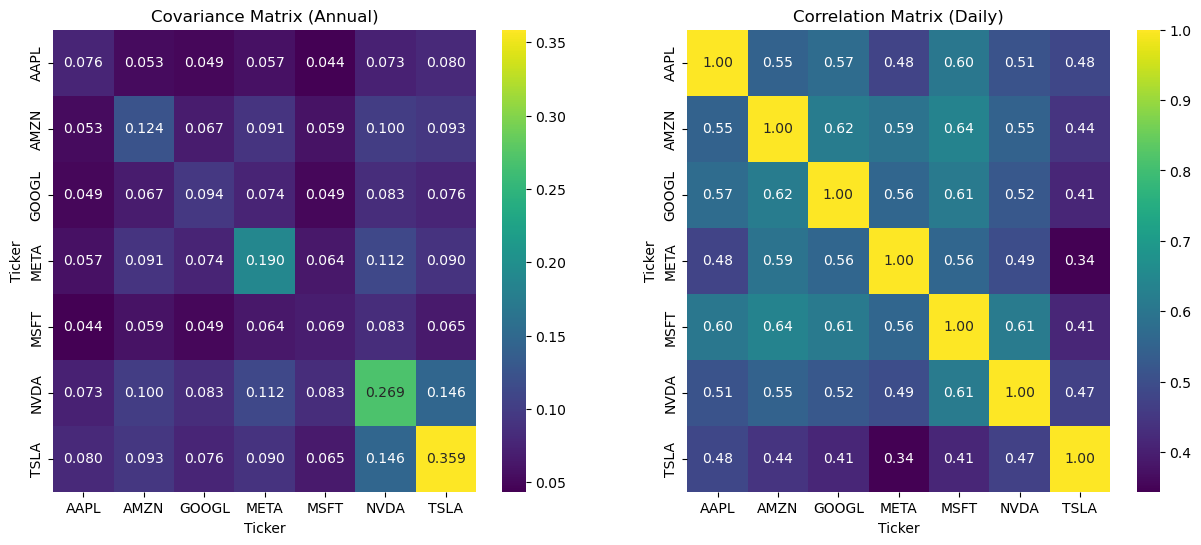

In [3]:
mu_annual, sigma_annual, cov_annual = returns_volatility(dataM7)

## 4. Efficient Frontier - Markowitz Model

Once the data and signals have been prepared and checked, we move on to the optimization.  

First, the minimum and maximum annual returns are calculated to generate the target returns vector.

Then the frontier values are calculated, 'frontier_volatilities', 'frontier_returns', and 'frontier_weights' to generate the curve.
This is done by the function `frontier_optimizer()`.

Once the frontier is defined, thousands of random portfolios are calculated using the Monte Carlo simulation method.

In [4]:
return_min = mu_annual.min()  # lowest individual asset return
return_max = mu_annual.max()  # highest individual asset return
target_returns = np.linspace(return_min, return_max, 100)
frontier_volatilities, frontier_returns, frontier_weights = frontier_optimizer(mu_annual, sigma_annual, cov_annual, target_returns)

In [5]:
n_simulations = 10_000
sim_returns, sim_vols, sim_sharpes = [], [], []

for _ in range(n_simulations):
    w = np.random.dirichlet(np.ones(len(assets)))
    r = portfolio_return(w, mu_annual)
    v = portfolio_volatility(w, cov_annual)
    s = (r - 0.04) / v
    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

## 5. Key Portfolios

After the frontier and random portfolios are calculated, we proceed to calculate the key portfolios for comparison.
   - The first is the portfolio with equally distributed weight. This will serve as a benchmark, as it has not been optimized.
   - The second optimizes the target return, aiming to minimize volatility but to obtain the same returns as the benchmark.
   - The third finds the portfolio with the absolute minimum volatility, the leftmost point on the frontier curve.
   - The fourth optimizes the Sharpe ratio without any constraints.

In [6]:
# Equal-weight portfolio

w_equal = np.ones(len(assets)) / len(assets)

# Equal weight portfolio stats
w_equal = np.ones(len(assets)) / len(assets)
ret_equal = portfolio_return(w_equal, mu_annual)
vol_equal = portfolio_volatility(w_equal, cov_annual)
sharpe_equal = (ret_equal - 0.04) / vol_equal

# display(pd.Series(w_equal, index=assets).round(4))

port_value_eq = portfolio_value(starting_capital, dataM7, w_equal)

In [7]:
# Optimizing the portfolio weight to obtain the same returns as the equally distributed weights but minimizing the volatility

# Now find the frontier portfolio at the same return
result = min_variance(ret_equal, mu_annual, cov_annual)
w_optimized = result.x
vol_optimized = portfolio_volatility(w_optimized, cov_annual)

print(f"Equal weight: ret={ret_equal:.3f}, vol={vol_equal:.3f}, sharpe={sharpe_equal:.3f}")
print(f"Optimized:    ret={ret_equal:.3f}, vol={vol_optimized:.3f}")
print(f"Volatility reduction: {(vol_optimized/vol_equal - 1)*100:.1f}%")

# display(pd.Series(w_optimized, index=assets).round(4))

port_value_op = portfolio_value(starting_capital, dataM7, w_optimized)

Equal weight: ret=0.360, vol=0.299, sharpe=1.069
Optimized:    ret=0.360, vol=0.266
Volatility reduction: -11.3%


In [8]:
# calculating the case with the minimum volatility from the efficient frontier

idx = np.argmin(frontier_volatilities)
min_vol = frontier_volatilities[idx]
min_ret = frontier_returns[idx]
min_w = frontier_weights[idx]


print(f"Returns: {min_ret:.4f}")
print(f"Min. Volatility: {min_vol:.4f}")


# display(pd.Series(min_w, index=assets).round(4))

port_value_mi = portfolio_value(starting_capital, dataM7, min_w)

Returns: 0.2042
Min. Volatility: 0.2372


In [9]:
# calculating the weights for maximum Sharpe value
    
sharpe_result = max_sharpe(mu_annual, cov_annual)
sharpe_weights = sharpe_result.x
sharpe_ret = portfolio_return(sharpe_weights, mu_annual)
sharpe_vol = portfolio_volatility(sharpe_weights, cov_annual)


print(f"Sharpe Returns: {sharpe_ret:.4f}")
print(f"Sharpe Volatility: {sharpe_vol:.4f}")
print(f"Sharpe Ratio: {sharpe_result.fun:.4f}")


# display(pd.Series(sharpe_weights, index=assets).round(4))

port_value_sh = portfolio_value(starting_capital, dataM7, sharpe_weights)

Sharpe Returns: 0.9753
Sharpe Volatility: 0.5184
Sharpe Ratio: -1.8043


## 6. Black-Litterman Model

After finishing the previous calculation and seeing some limitations of the Markowitz model, we ran a few extra calculations.
    - The current market cap values are used to calculate weights for each of the assets.
    - Outperformers and underperformers are selected, as well as an outerperformance percentage.
    - Posterior returns are calculated, and the optimization is rerun with the new values.
    - Sensitivity test


The signs indicate direction — positive assets are expected to outperform, negative ones underperform. Normalized weights ensure the view is about *relative* performance, not absolute levels.

**The full Black-Litterman formula for posterior returns:**

μ_BL = [(τΣ)⁻¹ + P^T Ω⁻¹ P]⁻¹ × [(τΣ)⁻¹ π + P^T Ω⁻¹ Q]


In [11]:
# Step 1 - Market cap weights
w_market = capsM7["MarketCap"]/capsM7["MarketCap"].sum()

# display(pd.Series(w_market.values, index=assets).round(4))

# Step 2 - Equilibrium returns
lam = 2.5
pi = lam * cov_annual @ w_market

# Step 3 - Black-Litterman posterior
tau = 0.05

# Outperformers get +1/4, underperformers get -1/3
# (normalized so each side sums to 1)
P = np.array([[1/4, -1/3, 1/4, -1/3, 1/4, 1/4, -1/3]])
#              AAPL  AMZN  GOOGL META  MSFT  NVDA  TSLA
Q = np.array([0.05]) # 5% outperformance
omega = tau * P @ cov_annual @ P.T  # proportional to variance of views

# second run
# omega = np.diag([0.001])  # high confidence, small uncertainty
# Q = np.array([0.10])  # you believe 10% outperformance

# Posterior returns
M1 = np.linalg.inv(tau * cov_annual)
M2 = P.T @ np.linalg.inv(omega) @ P
M3 = M1 @ pi + P.T @ np.linalg.inv(omega) @ Q
mu_bl = np.linalg.solve(M1 + M2, M3)

display(pd.DataFrame({"Ticker": pi.index, "pi": pi.values, "mu_bl": mu_bl}))

,Ticker,pi,mu_bl
0,AAPL,0.154209,0.151835
1,AMZN,0.201586,0.176552
2,GOOGL,0.176130,0.173386
3,META,0.224851,0.189679
4,MSFT,0.154552,0.153649
5,NVDA,0.324732,0.330649
6,TSLA,0.284784,0.217911


In [12]:
# BL optimization

# Market weights
ret_equal = portfolio_return(w_market, mu_bl)
vol_equal = portfolio_volatility(w_market, cov_annual)
sharpe_equal = (ret_equal - 0.04) / vol_equal


# Now find the frontier portfolio at the same return
result = min_variance(ret_equal, mu_bl, cov_annual)
w_optimized_BL = result.x
vol_optimized_BL = portfolio_volatility(w_optimized, cov_annual)

print(f"Market weight: ret={ret_equal:.3f}, vol={vol_equal:.3f}, sharpe={sharpe_equal:.3f}")
print(f"Optimized:     ret={ret_equal:.3f}, vol={vol_optimized:.3f}")
print(f"Volatility reduction: {(vol_optimized/vol_equal - 1)*100:.1f}%")

# display(pd.Series(w_optimized_BL, index=assets).round(4))

port_value_bl = portfolio_value(starting_capital, dataM7, w_market)

Market weight: ret=0.205, vol=0.294, sharpe=0.562
Optimized:     ret=0.205, vol=0.266
Volatility reduction: -9.5%


## 7. Visualisation
Three main plots are show summarizing our findings:
   1. Frontier plot with Monte Carlo coloured by Sharpe showing:
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
   2. Portfolio value over 5 years showing:
        - Benchmark portfolio
        - Optimized weight for target returns
        - Minimum volatility
        - Maximum Sharpe
        - Black-Litterman optimization
        - SPY as reference
   3. Weight distribution for all assets showing:
        - Benchmark portfolio (equal weights)
        - Optimized weight for target returns
        - Minimum volatility
        - Maximum Sharpe
        - Black-Litterman optimization

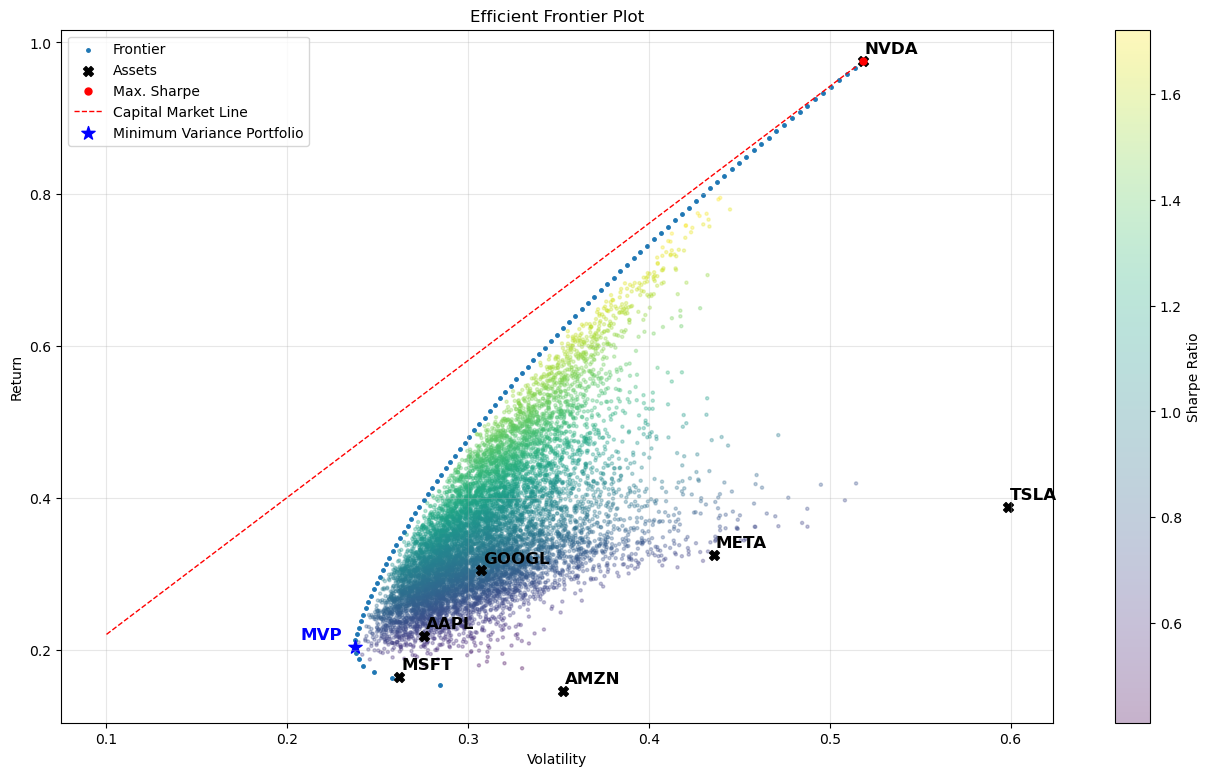

In [14]:
plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.scatter(frontier_volatilities, frontier_returns, s=25, marker='.', label='Frontier')

plt.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(sigma_annual, mu_annual, s=50, c='k', marker='X', label='Assets')
for asset in assets:
    plt.annotate(asset, (sigma_annual[asset]+0.001, mu_annual[asset]+0.01),fontweight='bold',fontsize=12)

plt.scatter(sharpe_vol, sharpe_ret, s=25, c='r', marker='o', label='Max. Sharpe')

# CML: from (0, rf) through (sharpe_vol, sharpe_ret)
cml_x = np.linspace(0.1, max(sim_vols), 100)
cml_y = 0.04 + (sharpe_ret - 0.04) / sharpe_vol * cml_x
plt.plot(cml_x, cml_y, 'r--', linewidth=1, label='Capital Market Line')

plt.scatter(min_vol, min_ret, s=100, c='b', marker='*', label='Minimum Variance Portfolio')
plt.annotate('MVP', (min_vol-0.03, min_ret+0.01),fontweight='bold',fontsize=12, color='b')

plt.grid(True, alpha=0.3)
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.title('Efficient Frontier Plot')
plt.show()

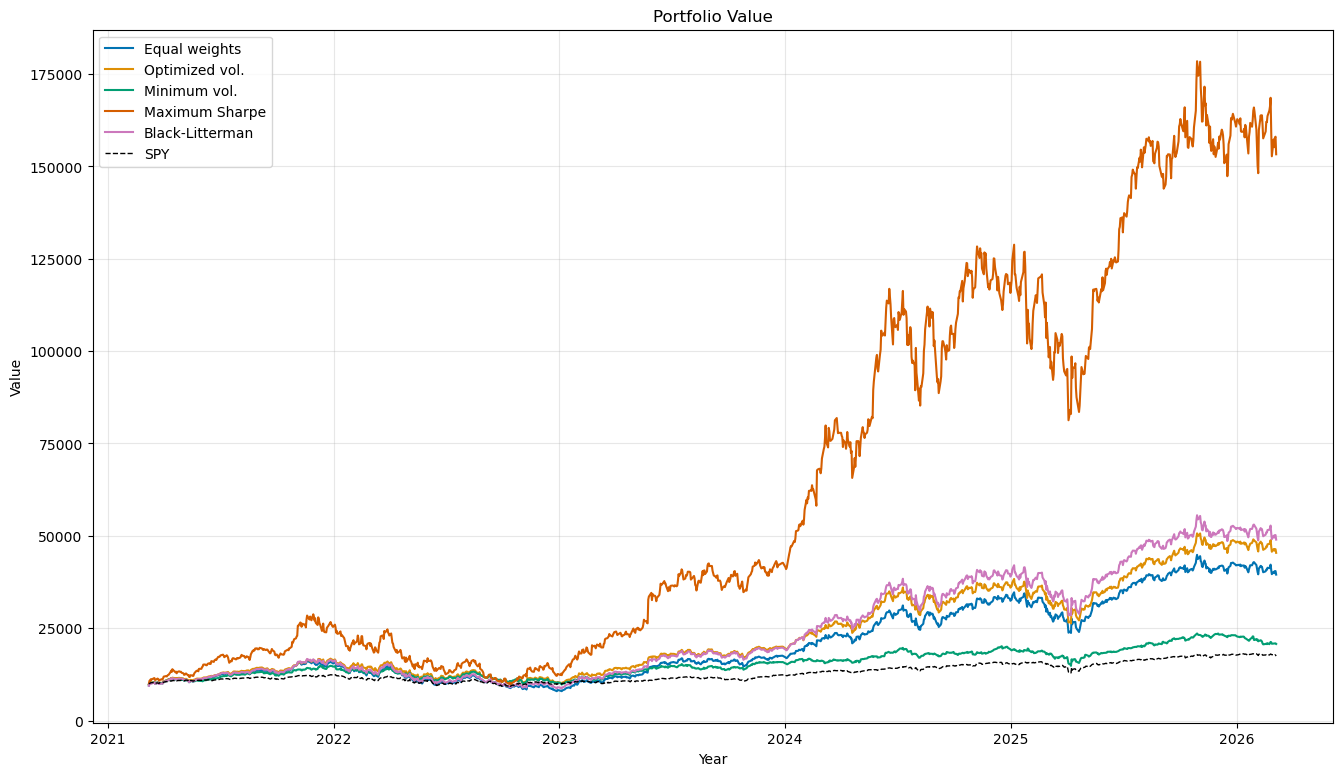

In [15]:
port_value_sp = portfolio_value(starting_capital, dataS, 1)

plt.figure(figsize=(16, 9))

colors = sns.color_palette("colorblind")

plt.plot(port_value_eq, color=colors[0], label='Equal weights')
plt.plot(port_value_op, color=colors[1], label='Optimized vol.')
plt.plot(port_value_mi, color=colors[2], label='Minimum vol.')
plt.plot(port_value_sh, color=colors[3], label='Maximum Sharpe')
plt.plot(port_value_bl, color=colors[4], label='Black-Litterman')
plt.plot(port_value_sp, 'k--', linewidth=1, label='SPY')


plt.title('Portfolio Value')
plt.xlabel('Year')
plt.ylabel('Value')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

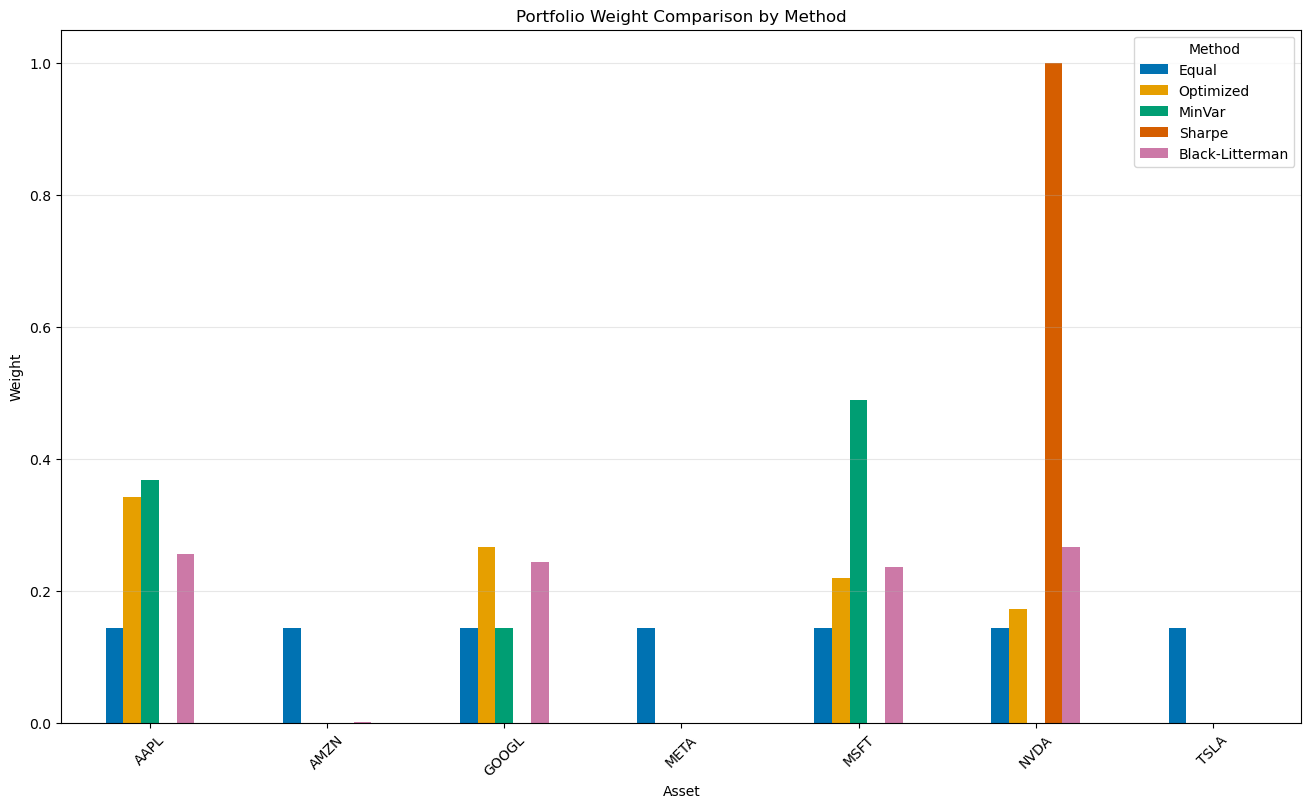

In [18]:
weights_df = pd.DataFrame({
    "Equal": w_equal,
    "Optimized": w_optimized,
    "MinVar": min_w,
    "Sharpe": sharpe_weights,
    "Black-Litterman": w_optimized_BL,
    },
    index=assets
)

colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#F0E442", "#56B4E9", "#000000"
]

weights_df.plot(kind="bar", figsize=(16, 9), color=colors[:len(weights_df.columns)])

plt.title("Portfolio Weight Comparison by Method")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Method")

plt.show()

## 8. Conclusions

For this particular scenario, in which we look back at 5-year data from the *"Magnificent 7"* stocks (Apple, Amazon, Google, Meta, Microsoft, Nvidia, & Tesla) with equally distributed weights (14.3% each) and optimized the asset allocation to minimize volatility and maximize returns, we can draw the following conclusions:

- Assets that perform poorly on their own are kept, meaning that diversification benefit through low correlation was achieved. An asset isn't evaluated in isolation, but rather it's evaluated by its marginal contribution to portfolio variance. META kept appearing despite our skepticism because its correlation with the other assets is the lowest in the matrix. This is the single most counterintuitive insight in portfolio theory.
- Assets with too much volatility and poor returns are minimized or removed completely. This is the optimizer enforcing the efficiency principle — no rational investor should hold an asset inside the frontier when a better risk/return combination exists. TSLA and AMZN repeatedly got zeroed out because they contribute volatility without sufficient return compensation.
- The Markowitz model has the limitation of only looking at past data. This is called estimation error in expected returns. Small changes in historical return estimates produce wildly different optimal weights — the optimizer is hypersensitive to inputs. However, the Black-Litterman model stabilizes this by anchoring to market equilibrium and blending in views with explicit confidence levels. The result is more robust, more diversified portfolios that don't collapse to a single asset.
- Weights are derived from historical data and evaluated on the same historical period. This is an acknowledged limitation — the portfolio value comparison is illustrative of how the optimization framework behaves, not a prediction of future performance.

## 9. Limitations & Next Steps

The three most important limitations of this model are the following:  
1. Estimation error — optimal weights are highly sensitive to expected return inputs. Small changes in historical returns produce dramatically different portfolios. The 100% NVDA result from raw Markowitz illustrates this failure mode clearly. Black-Litterman partially addresses this but doesn't eliminate it.
2. Static weights — the optimized portfolio is calculated once and held fixed. In reality, correlations and volatilities change over time. A portfolio optimal today may be inefficient in 6 months. A rolling or dynamic rebalancing framework is needed for real deployment.
3. In-sample optimization — weights are optimized on the same data used to evaluate performance. The portfolio value comparison is therefore illustrative, not predictive. A proper evaluation requires out-of-sample testing on held-out data.

Some interesting next steps to go deeper on this project would be:
- Implement rolling window optimization — recalculate weights every quarter using only past data
- Add rebalancing costs — frequent rebalancing erodes returns
- Extend to mixed asset classes — stocks, crypto, ETFs (Q4)
- Explore Lyapunov stability-based rebalancing as a novel contribution (Q6)

Just to name a few.